# Last.fm Global Trends - Explorer

Quick exploration of the `trends.db` dataset using DuckDB and pandas.

- **Global** — top artists, tracks, and tags worldwide
- **By Country** — top artists and tracks for any supported country

In [1]:
!pip install -q duckdb

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DB_PATH = "/kaggle/input/datasets/tiagoadrianunes/last-fm-global-trends/trends.db"

con = duckdb.connect(DB_PATH, read_only=True)

# Quick sanity check
for table in ["global_top_artists", "global_top_tracks", "global_top_tags", "geo_top_artists", "geo_top_tracks"]:
    count = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"  {table}: {count:,} rows")

  global_top_artists: 10,000 rows
  global_top_tracks: 9,999 rows
  global_top_tags: 10,000 rows
  geo_top_artists: 584,645 rows
  geo_top_tracks: 1,744,010 rows


## Global Top Artists

In [3]:
top_artists = con.execute("""
    SELECT rank AS "Rank", artist AS "Artist",
           listeners AS "Listeners", playcount AS "Scrobbles"
    FROM global_top_artists
    ORDER BY rank
    LIMIT 25
""").df()

top_artists[["Listeners", "Scrobbles"]] = top_artists[["Listeners", "Scrobbles"]].apply(
    lambda c: c.map("{:,}".format)
)
top_artists.set_index("Rank")

,Artist,Listeners,Scrobbles
Rank,,,
1,Kanye West,"7,936,473","1,532,130,933"
2,PinkPantheress,"3,052,893","324,172,125"
3,Tame Impala,"4,349,438","415,098,299"
4,The Weeknd,"5,299,551","1,116,795,474"
5,Lady Gaga,"7,701,554","1,029,046,549"
6,Radiohead,"8,218,757","1,369,003,172"
7,Rihanna,"8,275,702","599,024,865"
8,Kendrick Lamar,"5,082,092","1,027,206,991"
9,Sabrina Carpenter,"3,236,216","656,573,073"


### Top 20 Artists by Scrobbles

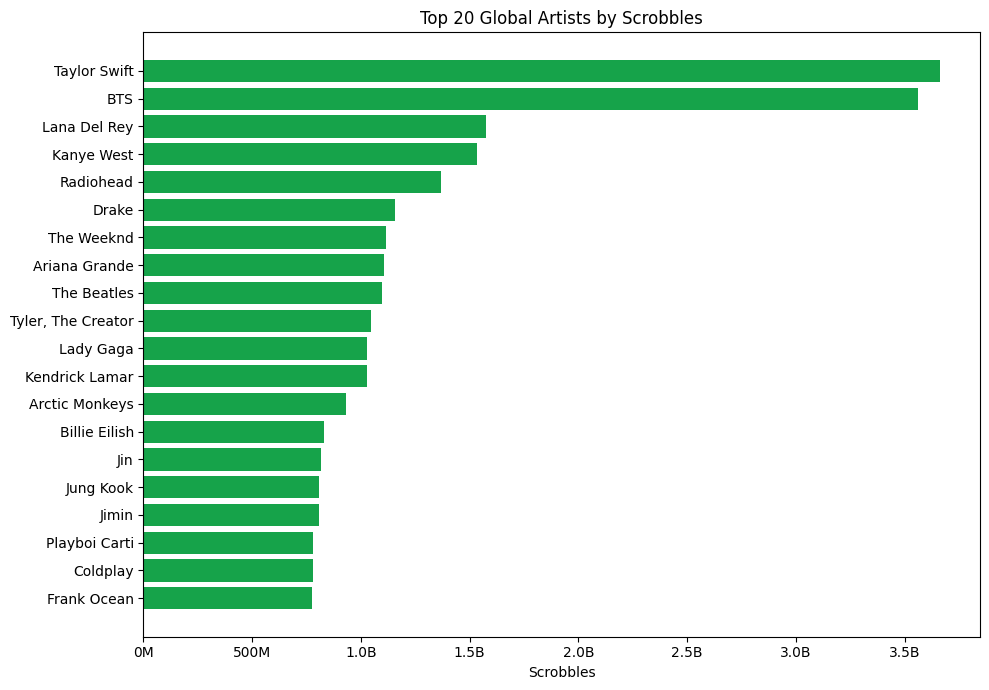

In [4]:
chart_df = con.execute("""
    SELECT artist, playcount
    FROM global_top_artists
    ORDER BY playcount DESC
    LIMIT 20
""").df().sort_values("playcount")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(chart_df["artist"], chart_df["playcount"], color="#16a34a")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e9:.1f}B" if x >= 1e9 else f"{x/1e6:.0f}M"))
ax.set_xlabel("Scrobbles")
ax.set_title("Top 20 Global Artists by Scrobbles")
plt.tight_layout()
plt.show()

## Global Top Tracks

In [5]:
top_tracks = con.execute("""
    SELECT rank AS "Rank", track AS "Track", artist AS "Artist",
           listeners AS "Listeners", playcount AS "Scrobbles"
    FROM global_top_tracks
    ORDER BY rank
    LIMIT 25
""").df()

top_tracks[["Listeners", "Scrobbles"]] = top_tracks[["Listeners", "Scrobbles"]].apply(
    lambda c: c.map("{:,}".format)
)
top_tracks.set_index("Rank")

,Track,Artist,Listeners,Scrobbles
Rank,,,,
1,Stateside + Zara Larsson,PinkPantheress,"1,148,725","18,108,358"
2,Babydoll,Dominic Fike,"1,608,071","24,047,185"
3,Manchild,Sabrina Carpenter,"1,242,197","24,492,471"
4,SWIM,BTS,"394,755","88,214,679"
5,Dracula - JENNIE remix,Tame Impala,"523,549","3,734,454"
6,House Tour,Sabrina Carpenter,"724,798","12,154,341"
7,Earrings,Malcolm Todd,"585,123","7,485,855"
8,Body to Body,BTS,"367,303","28,475,605"
9,Fame Is a Gun,Addison Rae,"1,027,273","19,808,265"


### Artists With Most Tracks in Global Top 10,000

In [6]:
artist_counts = con.execute("""
    SELECT artist AS "Artist", COUNT(*) AS "Tracks in Top 10k"
    FROM global_top_tracks
    GROUP BY artist
    ORDER BY 2 DESC
    LIMIT 20
""").df()

artist_counts.index = range(1, len(artist_counts) + 1)
artist_counts.index.name = "Rank"
artist_counts

,Artist,Tracks in Top 10k
Rank,,
1,Taylor Swift,212
2,BTS,187
3,Drake,119
4,Kanye West,119
5,Ariana Grande,87
6,Lana Del Rey,81
7,Playboi Carti,70
8,"Tyler, The Creator",69
9,Kendrick Lamar,67


## Global Top Tags

In [7]:
top_tags = con.execute("""
    SELECT rank AS "Rank", tag AS "Tag",
           reach AS "Reach", taggings AS "Taggings"
    FROM global_top_tags
    ORDER BY rank
    LIMIT 25
""").df()

top_tags[["Reach", "Taggings"]] = top_tags[["Reach", "Taggings"]].apply(
    lambda c: c.map("{:,}".format)
)
top_tags.set_index("Rank")

,Tag,Reach,Taggings
Rank,,,
1,rock,"402,977","4,070,152"
2,electronic,"262,308","2,500,121"
3,seen live,"82,562","2,195,072"
4,alternative,"267,251","2,131,271"
5,pop,"233,838","2,083,578"
6,indie,"260,515","2,065,695"
7,female vocalists,"169,173","1,634,741"
8,metal,"159,042","1,306,039"
9,alternative rock,"170,301","1,231,288"


## By Country

Change `COUNTRY` to any supported country name (e.g. `"Brazil"`, `"Japan"`, `"Germany"`).

In [8]:
COUNTRY = "United States"

# Available countries
available = con.execute(
    "SELECT DISTINCT country FROM geo_top_artists ORDER BY country"
).df()["country"].tolist()
print(f"{len(available)} countries available")
print(", ".join(available[:20]), "...")

228 countries available
Afghanistan, Albania, Algeria, American Samoa, Andorra, Angola, Anguilla, Antarctica, Antigua and Barbuda, Argentina, Armenia, Aruba, Australia, Austria, Azerbaijan, Bahamas, Bahrain, Bangladesh, Barbados, Belarus ...


### Top Artists by Country

In [9]:
geo_artists = con.execute("""
    SELECT rank AS "Rank", artist AS "Artist", listeners AS "Listeners"
    FROM geo_top_artists
    WHERE country = ?
    ORDER BY rank
    LIMIT 25
""", [COUNTRY]).df()

geo_artists["Listeners"] = geo_artists["Listeners"].map("{:,}".format)
geo_artists.set_index("Rank")

,Artist,Listeners
Rank,,
1,Kanye West,"265,986"
2,"Tyler, The Creator","235,080"
3,Drake,"233,205"
4,Kendrick Lamar,"228,080"
5,PinkPantheress,"221,691"
6,Radiohead,"211,267"
7,Tame Impala,"201,551"
8,The Weeknd,"198,968"
9,Rihanna,"195,052"


### Top Tracks by Country

In [10]:
geo_tracks = con.execute("""
    SELECT rank AS "Rank", track AS "Track", artist AS "Artist", listeners AS "Listeners"
    FROM geo_top_tracks
    WHERE country = ?
    ORDER BY rank
    LIMIT 25
""", [COUNTRY]).df()

geo_tracks["Listeners"] = geo_tracks["Listeners"].map("{:,}".format)
geo_tracks.set_index("Rank")

,Track,Artist,Listeners
Rank,,,
1,Stateside + Zara Larsson,PinkPantheress,"112,392"
2,Earrings,Malcolm Todd,"81,656"
3,Babydoll,Dominic Fike,"69,132"
4,In My Room,Julia Wolf,"60,364"
5,Sweet Boy,Malcolm Todd,"55,541"
6,House Tour,Sabrina Carpenter,"54,735"
7,E85,Don Toliver,"54,597"
8,505,Arctic Monkeys,"54,332"
9,Beauty and a Beat,Justin Bieber,"54,177"


### Top 20 Artists by Listeners — Country Chart

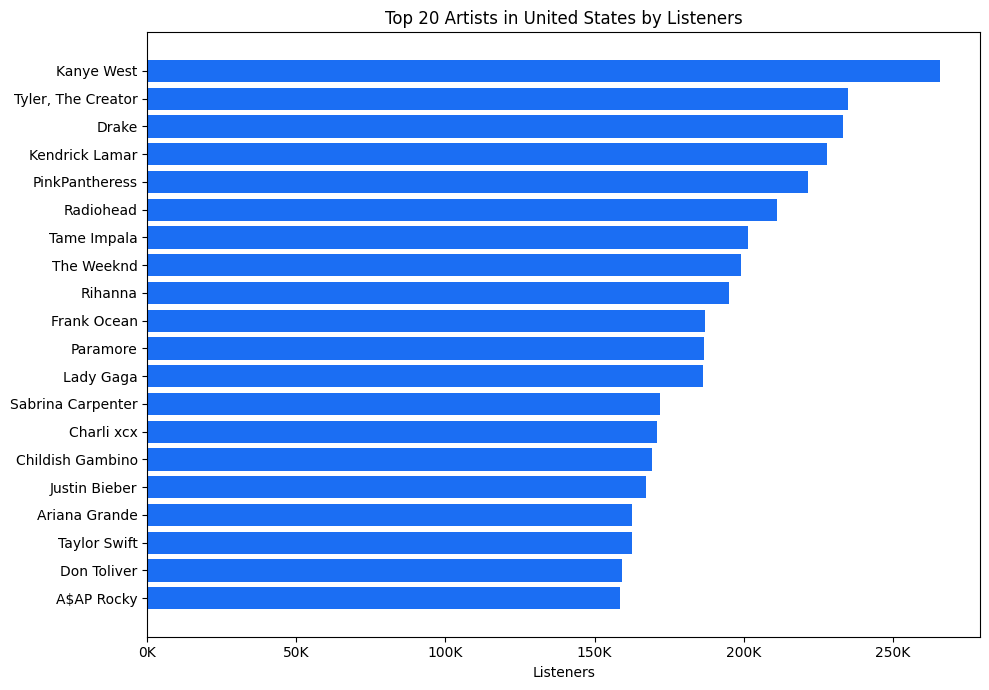

In [11]:
geo_chart = con.execute("""
    SELECT artist, listeners
    FROM geo_top_artists
    WHERE country = ?
    ORDER BY listeners DESC
    LIMIT 20
""", [COUNTRY]).df().sort_values("listeners")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(geo_chart["artist"], geo_chart["listeners"], color="#1b6ef3")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
ax.set_xlabel("Listeners")
ax.set_title(f"Top 20 Artists in {COUNTRY} by Listeners")
plt.tight_layout()
plt.show()

In [12]:
con.close()